In [ ]:
import os
import gymnasium as gym
import numpy as np



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("Taxi-v3" , render_mode = 'rgb_array')

In [ ]:
state = env.reset()

In [ ]:
state

(483, {'prob': 1.0, 'action_mask': array([0, 1, 0, 1, 0, 0], dtype=int8)})

In [ ]:
env.observation_space.n

np.int64(500)

In [ ]:
env.action_space.n

np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
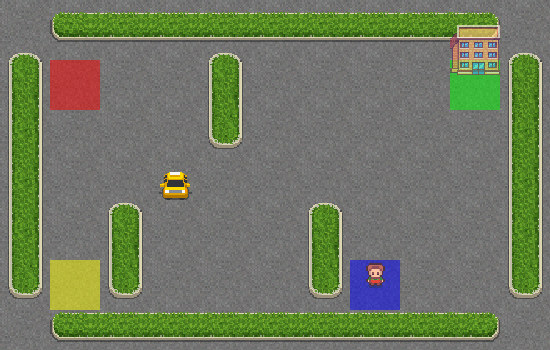

In [ ]:
env.render()

In [ ]:
env.step(4)

(233,
 -10,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

**down(0),up(1),right(2),left(3),pick-up(4),drop-off(5)**

In [ ]:
n_states=env.observation_space.n
n_actions =env.action_space.n
n_actions

np.int64(6)

In [ ]:
state = env.reset()
counter =0
g=0
reward = None

In [ ]:
while reward!= 20:
  state,reward,terminated,truncated,info = env.step(env.action_space.sample())
  counter+=1
  g+=reward

In [ ]:
print("Solved in {} steps with a total reward of{}".format(counter,g))

Solved in 398 steps with a total reward of-1529


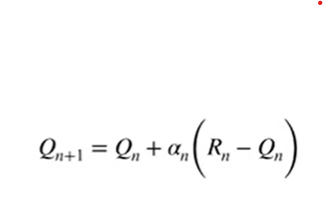

In [ ]:
Q = np.zeros((n_states,n_actions))

In [ ]:
n_actions

np.int64(6)

In [ ]:
episodes=2000
G=0
alpha =0.618

In [ ]:
for episode in range(1, episodes+1):
  steps_q_learning = 0
  G, reward=0,0
  state, _ = env.reset()
  state = int(state)
  finalState=state
  print(f"Initial state {state}")
  while reward != 20:
      action=np.argmax(Q[state])
      state2_tuple, reward, terminated, truncated, info  = env.step(action)
      state2 = int(state2_tuple)
      Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
      G += reward
      steps_q_learning += 1
      state=state2
  print(f"Episode {episode} solved in {steps_q_learning} steps with a total reward of {G}")

Initial state 151
Episode 1 solved in 35 steps with a total reward of -14
Initial state 146
Episode 2 solved in 16 steps with a total reward of 5
Initial state 24
Episode 3 solved in 134 steps with a total reward of -257
Initial state 262
Episode 4 solved in 40 steps with a total reward of -19
Initial state 8
Episode 5 solved in 27 steps with a total reward of -60
Initial state 274
Episode 6 solved in 28 steps with a total reward of -61
Initial state 1
Episode 7 solved in 10 steps with a total reward of 11
Initial state 291
Episode 8 solved in 19 steps with a total reward of 2
Initial state 427
Episode 9 solved in 39 steps with a total reward of -72
Initial state 301
Episode 10 solved in 20 steps with a total reward of 1
Initial state 73
Episode 11 solved in 40 steps with a total reward of -19
Initial state 72
Episode 12 solved in 110 steps with a total reward of -89
Initial state 103
Episode 13 solved in 14 steps with a total reward of 7
Initial state 112
Episode 14 solved in 93 steps

It is clear that after implementing ine episode of q learning it is better than random approach

In [ ]:
0

7